<a href="https://colab.research.google.com/github/HS-base/FYP/blob/main/Propane%2C_Butane%2C_Propylene.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Zeotropic Ammonia Blend Selection Methodology

The selection of the optimal working fluid blend for this analysis follows a multi-stage screening process based on thermophysical properties extracted from the **CoolProp** library.

### Phase 1: Initial Screening
The preliminary pool consists of ammonia-based blends with available data in CoolProp. The primary criterion for this stage is the presence of a suitable temperature glide.
* **Focus Area:** High ammonia mass fraction regions (approximately < 0.25).
* **Evaluation:** Thermal properties of these initial blends are plotted across three distinct operating pressures to observe glide behavior and general viability.

### Phase 2: Secondary Candidate Evaluation
Based on the initial screening, three promising zeotropic candidates advance to the next level of detailed thermodynamic analysis:
1. **Ammonia / Propane**
2. **Ammonia / Butane**
3. **Ammonia / Propylene**

To properly evaluate these candidates, the following phase properties are plotted for all three blends across the three selected pressures:
* Liquid saturation temperature
* Latent heat of vaporization
* Specific heat capacity of the liquid phase
* Specific heat capacity of the vapor phase

### Phase 3: Final Selection Criteria
The final blend selection is determined by optimizing for ideal cycle performance and efficient thermal energy conversion. The deciding thermodynamic factors are:
* **Latent Heat:** A minimized drop in the latent heat of vaporization.
* **Vapor Specific Heat:** A high specific heat capacity in the vapor phase.
* **Liquid Specific Heat:** A lowered specific heat capacity in the liquid phase.
* **The nature of the temperature glide:** The magnitude of the slope variation of saturation temperature should be noticed.

In [2]:
# @title
!pip install CoolProp

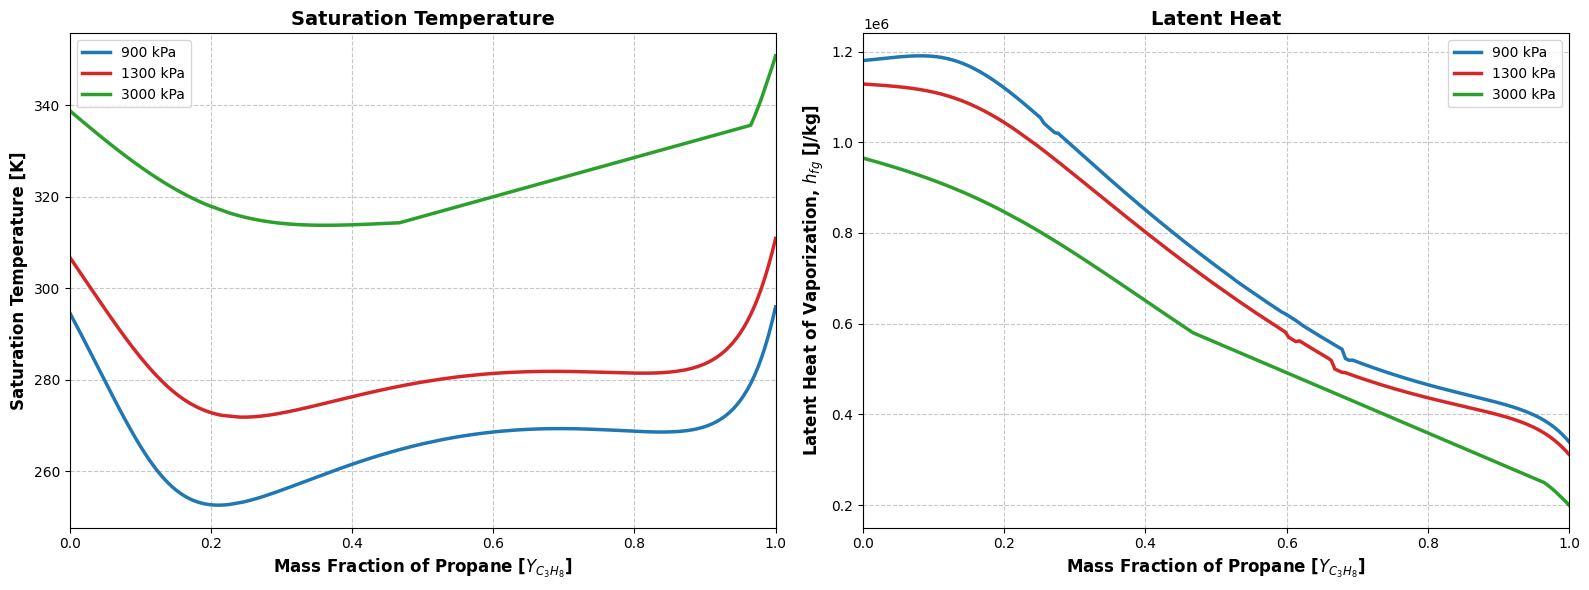

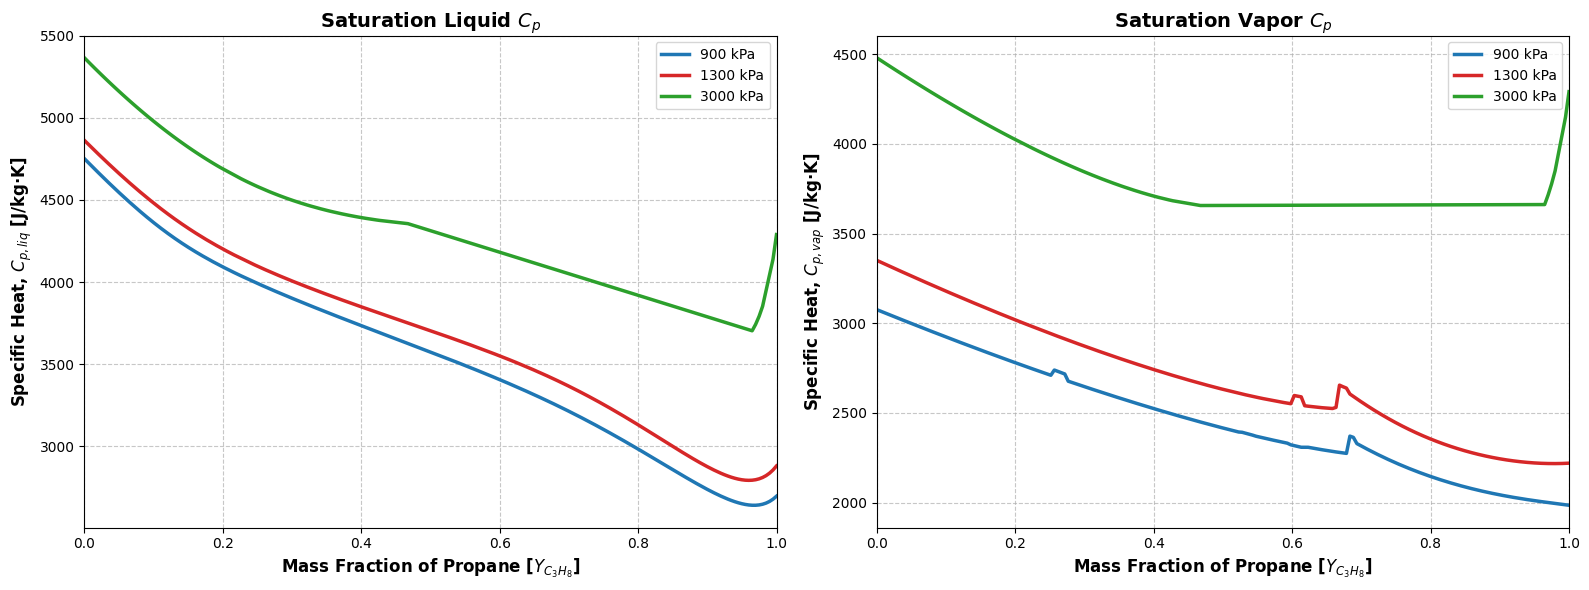

In [8]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def generate_thermodynamic_property_plots():
    """
    Evaluates and plots phase equilibrium and saturation properties for a specified
    binary mixture over a range of mass fractions and operating pressures.
    """

    # Define primary fluid mixture subsystem
    fluid_mixture = "Propane&Ammonia"
    state = CP.AbstractState("HEOS", fluid_mixture)

    # Specify operating pressure states (kPa)
    operating_pressures_kpa = [900, 1300, 3000]

    # Define independent variable domain: Mass fraction of the primary component
    # Utilizing a high resolution (100 points) to ensure smooth line interpolation
    mass_fractions = np.linspace(0.0, 1.0, 200)

    # Predefined color scheme for distinct pressure states
    plot_colors = ['#1f77b4', '#d62728', '#2ca02c']

    # Initialize plot environments
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    for idx, pressure_kpa in enumerate(operating_pressures_kpa):
        pressure_pa = pressure_kpa * 1000.0

        # Initialize data arrays for the current pressure state
        valid_mass_fractions = []
        saturation_temperatures = []
        latent_heats = []
        specific_heats_liquid = []
        specific_heats_vapor = []

        # Evaluate thermodynamic properties across the defined mass fraction domain
        for y_primary in mass_fractions:
            y_secondary = 1.0 - y_primary
            state.set_mass_fractions([y_primary, y_secondary])

            try:
                # Evaluate saturated liquid state (Vapor Quality = 0.0)
                state.update(CP.PQ_INPUTS, pressure_pa, 0.0)
                temp_sat = state.T()
                cp_liquid = state.cpmass()
                enthalpy_liquid = state.hmass()

                # Evaluate saturated vapor state (Vapor Quality = 1.0)
                state.update(CP.PQ_INPUTS, pressure_pa, 1.0)
                cp_vapor = state.cpmass()
                enthalpy_vapor = state.hmass()

                # Calculate latent heat of vaporization (h_fg = h_vapor - h_liquid)
                h_fg = enthalpy_vapor - enthalpy_liquid

                # Store converged data points
                valid_mass_fractions.append(y_primary)
                saturation_temperatures.append(temp_sat)
                latent_heats.append(h_fg)
                specific_heats_liquid.append(cp_liquid)
                specific_heats_vapor.append(cp_vapor)

            except ValueError:
                # Bypass states where the equation of state fails to converge
                pass

        # Convert lists to NumPy arrays for vectorized plotting
        x_data = np.array(valid_mass_fractions)
        t_data = np.array(saturation_temperatures)
        hfg_data = np.array(latent_heats)
        cp_l_data = np.array(specific_heats_liquid)
        cp_v_data = np.array(specific_heats_vapor)

        color = plot_colors[idx]
        label_str = f'{pressure_kpa} kPa'

        # --- Figure 1 Rendering ---
        # Render continuous lines joining the evaluated data points
        ax1.plot(x_data, t_data, linestyle='-', linewidth=2.5, color=color, label=label_str)
        ax2.plot(x_data, hfg_data, linestyle='-', linewidth=2.5, color=color, label=label_str)

        # --- Figure 2 Rendering ---
        ax3.plot(x_data, cp_l_data, linestyle='-', linewidth=2.5, color=color, label=label_str)
        ax4.plot(x_data, cp_v_data, linestyle='-', linewidth=2.5, color=color, label=label_str)

    # --- Standardize Figure 1 Layout & Typography ---
    ax1.set_xlabel('Mass Fraction of Propane [$Y_{C_3H_8}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Propane [$Y_{C_3H_8}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- Standardize Figure 2 Layout & Typography ---
    ax3.set_xlabel('Mass Fraction of Propane [$Y_{C_3H_8}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Propane [$Y_{C_3H_8}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Execute plot display
    plt.show()

if __name__ == '__main__':
    generate_thermodynamic_property_plots()

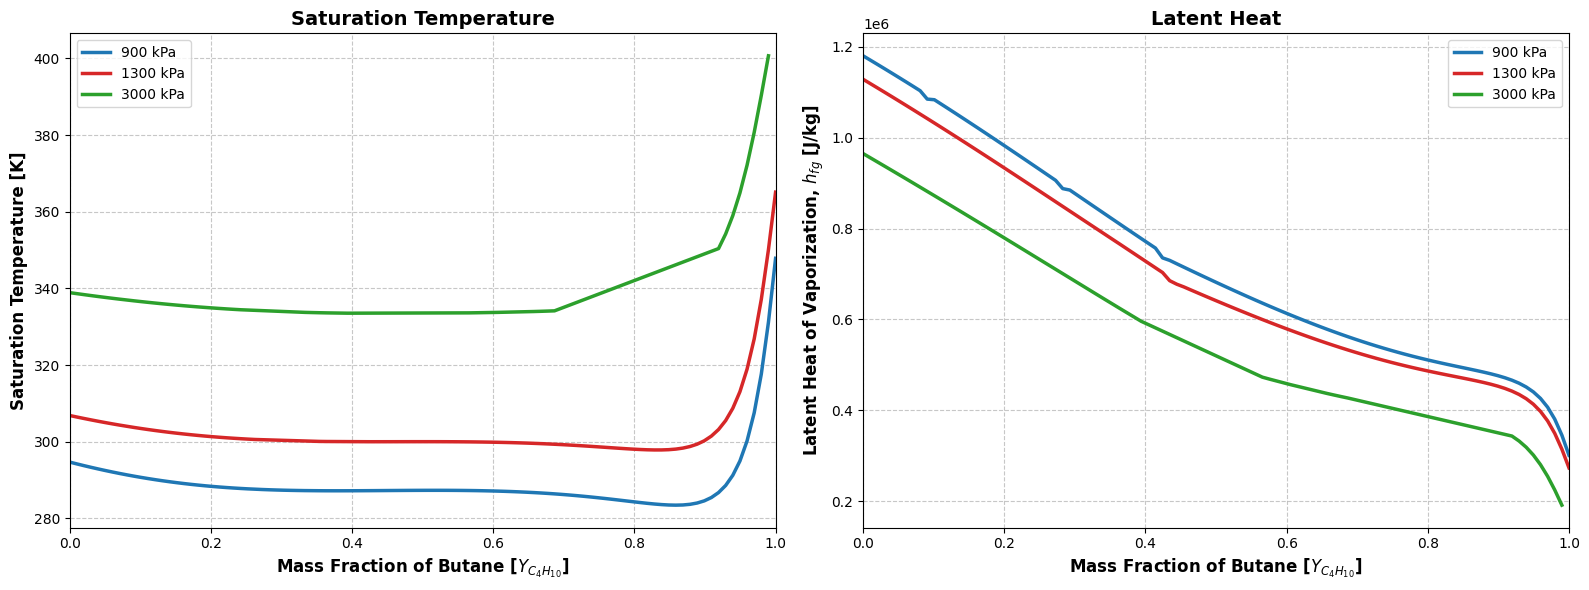

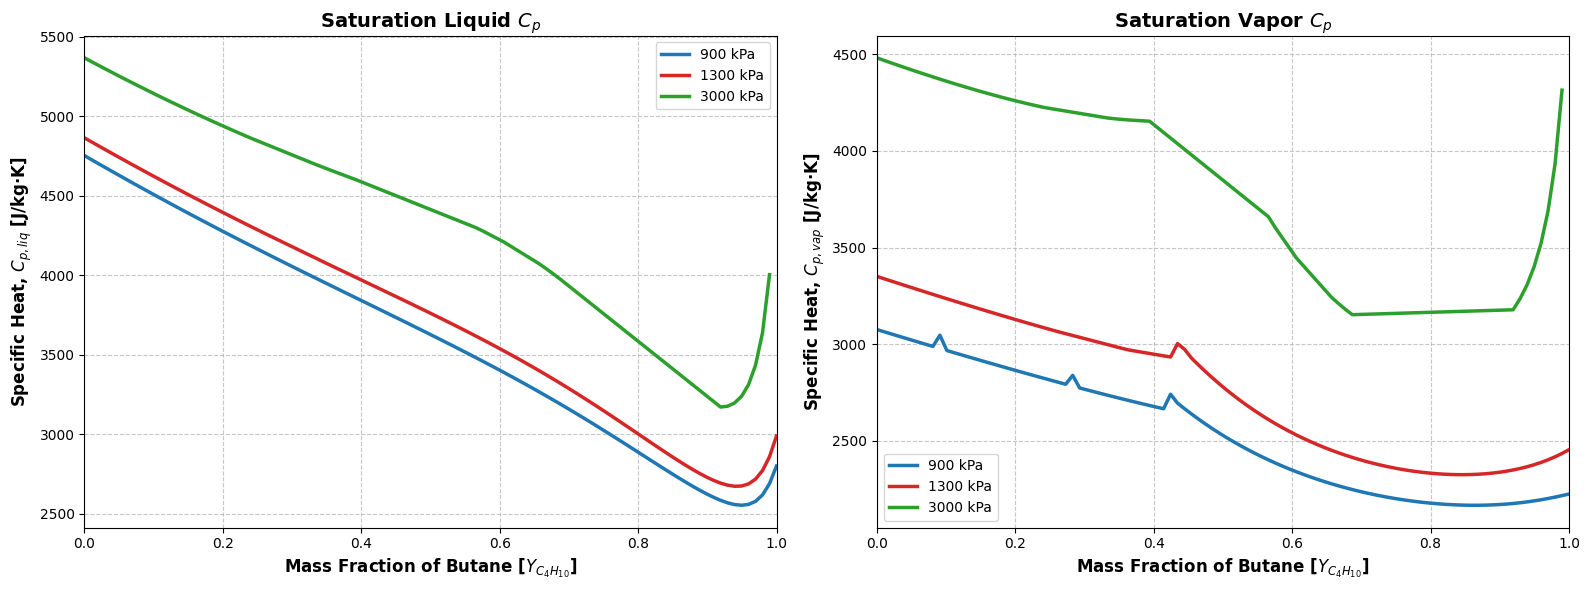

In [9]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def generate_thermodynamic_property_plots():
    """
    Evaluates and plots phase equilibrium and saturation properties for a specified
    binary mixture over a range of mass fractions and operating pressures.
    """

    # Define primary fluid mixture subsystem
    fluid_mixture = "Butane&Ammonia"
    state = CP.AbstractState("HEOS", fluid_mixture)

    # Specify operating pressure states (kPa)
    operating_pressures_kpa = [900, 1300, 3000]

    # Define independent variable domain: Mass fraction of the primary component
    # Utilizing a high resolution (100 points) to ensure smooth line interpolation
    mass_fractions = np.linspace(0.0, 1.0, 100)

    # Predefined color scheme for distinct pressure states
    plot_colors = ['#1f77b4', '#d62728', '#2ca02c']

    # Initialize plot environments
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    for idx, pressure_kpa in enumerate(operating_pressures_kpa):
        pressure_pa = pressure_kpa * 1000.0

        # Initialize data arrays for the current pressure state
        valid_mass_fractions = []
        saturation_temperatures = []
        latent_heats = []
        specific_heats_liquid = []
        specific_heats_vapor = []

        # Evaluate thermodynamic properties across the defined mass fraction domain
        for y_primary in mass_fractions:
            y_secondary = 1.0 - y_primary
            state.set_mass_fractions([y_primary, y_secondary])

            try:
                # Evaluate saturated liquid state (Vapor Quality = 0.0)
                state.update(CP.PQ_INPUTS, pressure_pa, 0.0)
                temp_sat = state.T()
                cp_liquid = state.cpmass()
                enthalpy_liquid = state.hmass()

                # Evaluate saturated vapor state (Vapor Quality = 1.0)
                state.update(CP.PQ_INPUTS, pressure_pa, 1.0)
                cp_vapor = state.cpmass()
                enthalpy_vapor = state.hmass()

                # Calculate latent heat of vaporization (h_fg = h_vapor - h_liquid)
                h_fg = enthalpy_vapor - enthalpy_liquid

                # Store converged data points
                valid_mass_fractions.append(y_primary)
                saturation_temperatures.append(temp_sat)
                latent_heats.append(h_fg)
                specific_heats_liquid.append(cp_liquid)
                specific_heats_vapor.append(cp_vapor)

            except ValueError:
                # Bypass states where the equation of state fails to converge
                pass

        # Convert lists to NumPy arrays for vectorized plotting
        x_data = np.array(valid_mass_fractions)
        t_data = np.array(saturation_temperatures)
        hfg_data = np.array(latent_heats)
        cp_l_data = np.array(specific_heats_liquid)
        cp_v_data = np.array(specific_heats_vapor)

        color = plot_colors[idx]
        label_str = f'{pressure_kpa} kPa'

        # --- Figure 1 Rendering ---
        # Render continuous lines joining the evaluated data points
        ax1.plot(x_data, t_data, linestyle='-', linewidth=2.5, color=color, label=label_str)
        ax2.plot(x_data, hfg_data, linestyle='-', linewidth=2.5, color=color, label=label_str)

        # --- Figure 2 Rendering ---
        ax3.plot(x_data, cp_l_data, linestyle='-', linewidth=2.5, color=color, label=label_str)
        ax4.plot(x_data, cp_v_data, linestyle='-', linewidth=2.5, color=color, label=label_str)

    # --- Standardize Figure 1 Layout & Typography ---
    ax1.set_xlabel('Mass Fraction of Butane [$Y_{C_4H_{10}}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Butane [$Y_{C_4H_{10}}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- Standardize Figure 2 Layout & Typography ---
    ax3.set_xlabel('Mass Fraction of Butane [$Y_{C_4H_{10}}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Butane [$Y_{C_4H_{10}}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Execute plot display
    plt.show()

if __name__ == '__main__':
    generate_thermodynamic_property_plots()

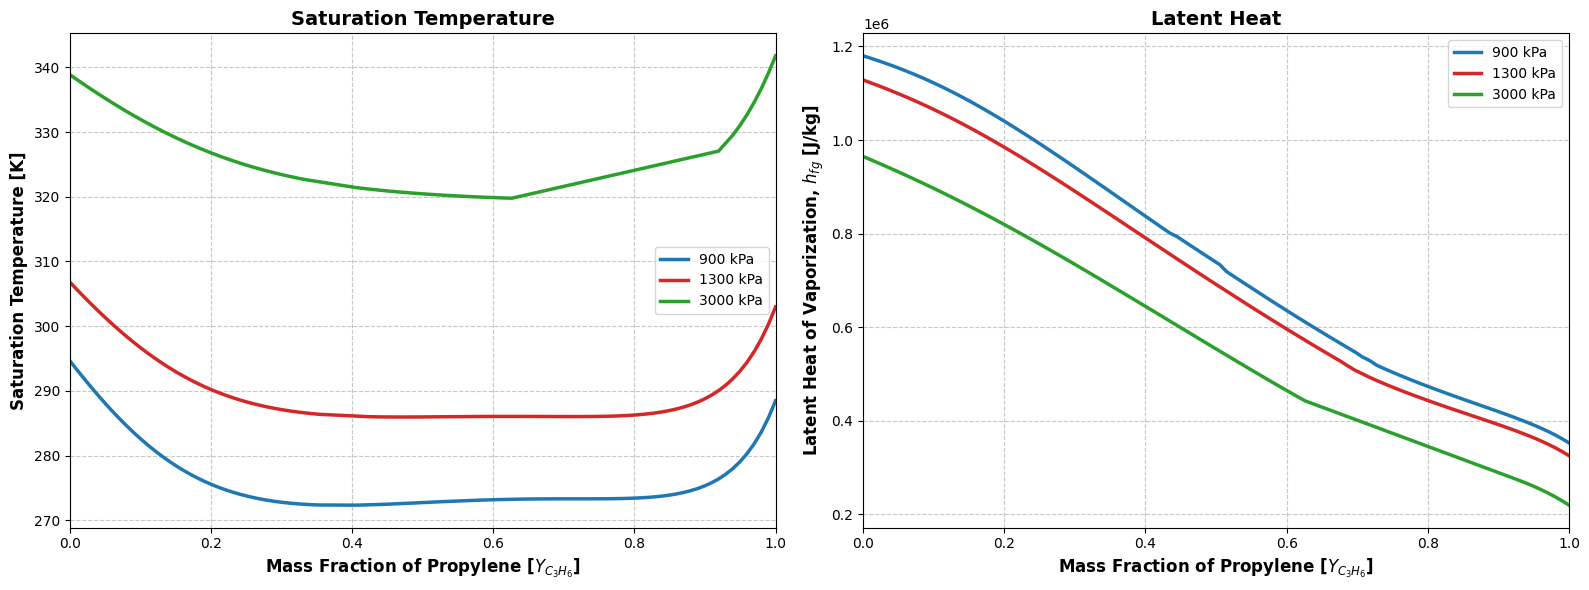

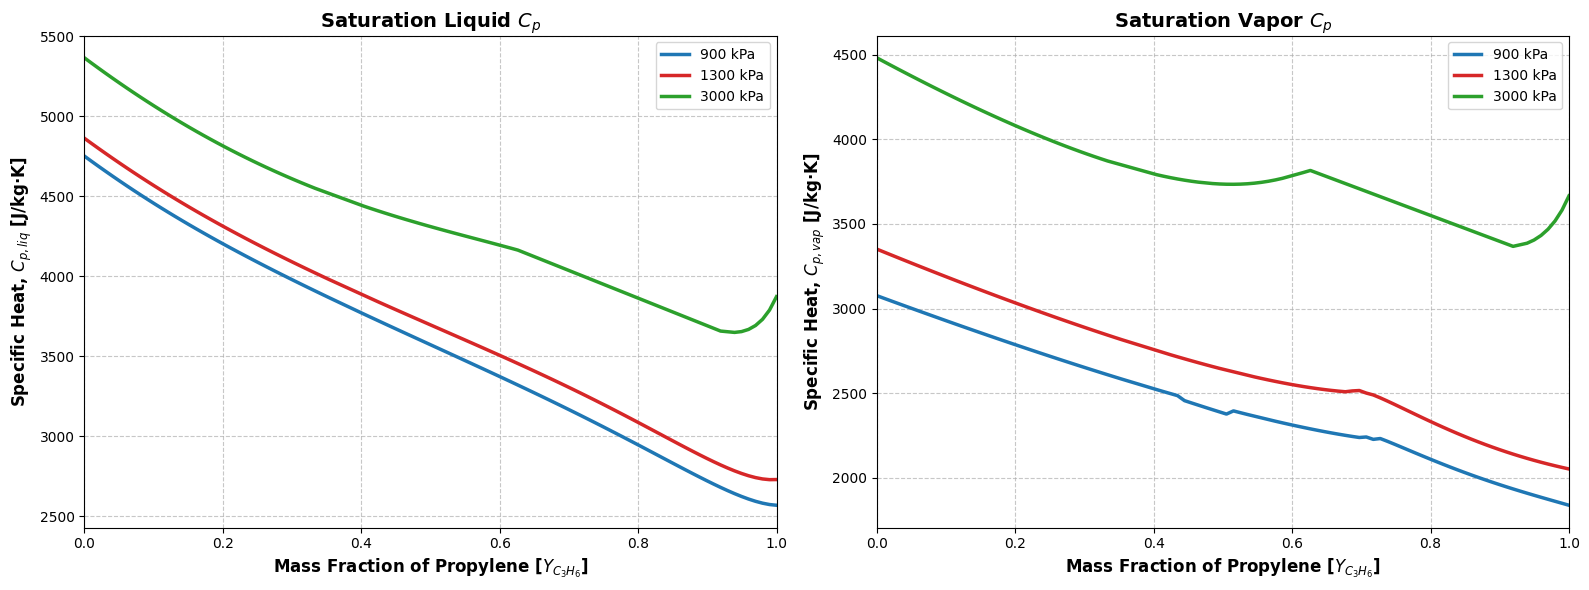

In [10]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def generate_thermodynamic_property_plots():
    """
    Evaluates and plots phase equilibrium and saturation properties for a specified
    binary mixture over a range of mass fractions and operating pressures.
    """

    # Define primary fluid mixture subsystem
    fluid_mixture = "Propylene&Ammonia"
    state = CP.AbstractState("HEOS", fluid_mixture)

    # Specify operating pressure states (kPa)
    operating_pressures_kpa = [900, 1300, 3000]

    # Define independent variable domain: Mass fraction of the primary component
    # Utilizing a high resolution (100 points) to ensure smooth line interpolation
    mass_fractions = np.linspace(0.0, 1.0, 100)

    # Predefined color scheme for distinct pressure states
    plot_colors = ['#1f77b4', '#d62728', '#2ca02c']

    # Initialize plot environments
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

    for idx, pressure_kpa in enumerate(operating_pressures_kpa):
        pressure_pa = pressure_kpa * 1000.0

        # Initialize data arrays for the current pressure state
        valid_mass_fractions = []
        saturation_temperatures = []
        latent_heats = []
        specific_heats_liquid = []
        specific_heats_vapor = []

        # Evaluate thermodynamic properties across the defined mass fraction domain
        for y_primary in mass_fractions:
            y_secondary = 1.0 - y_primary
            state.set_mass_fractions([y_primary, y_secondary])

            try:
                # Evaluate saturated liquid state (Vapor Quality = 0.0)
                state.update(CP.PQ_INPUTS, pressure_pa, 0.0)
                temp_sat = state.T()
                cp_liquid = state.cpmass()
                enthalpy_liquid = state.hmass()

                # Evaluate saturated vapor state (Vapor Quality = 1.0)
                state.update(CP.PQ_INPUTS, pressure_pa, 1.0)
                cp_vapor = state.cpmass()
                enthalpy_vapor = state.hmass()

                # Calculate latent heat of vaporization (h_fg = h_vapor - h_liquid)
                h_fg = enthalpy_vapor - enthalpy_liquid

                # Store converged data points
                valid_mass_fractions.append(y_primary)
                saturation_temperatures.append(temp_sat)
                latent_heats.append(h_fg)
                specific_heats_liquid.append(cp_liquid)
                specific_heats_vapor.append(cp_vapor)

            except ValueError:
                # Bypass states where the equation of state fails to converge
                pass

        # Convert lists to NumPy arrays for vectorized plotting
        x_data = np.array(valid_mass_fractions)
        t_data = np.array(saturation_temperatures)
        hfg_data = np.array(latent_heats)
        cp_l_data = np.array(specific_heats_liquid)
        cp_v_data = np.array(specific_heats_vapor)

        color = plot_colors[idx]
        label_str = f'{pressure_kpa} kPa'

        # --- Figure 1 Rendering ---
        # Render continuous lines joining the evaluated data points
        ax1.plot(x_data, t_data, linestyle='-', linewidth=2.5, color=color, label=label_str)
        ax2.plot(x_data, hfg_data, linestyle='-', linewidth=2.5, color=color, label=label_str)

        # --- Figure 2 Rendering ---
        ax3.plot(x_data, cp_l_data, linestyle='-', linewidth=2.5, color=color, label=label_str)
        ax4.plot(x_data, cp_v_data, linestyle='-', linewidth=2.5, color=color, label=label_str)

    # --- Standardize Figure 1 Layout & Typography ---
    ax1.set_xlabel('Mass Fraction of Propylene [$Y_{C_3H_6}$]', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Saturation Temperature [K]', fontsize=12, fontweight='bold')
    ax1.set_title('Saturation Temperature', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='best')

    ax2.set_xlabel('Mass Fraction of Propylene [$Y_{C_3H_6}$]', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latent Heat of Vaporization, $h_{fg}$ [J/kg]', fontsize=12, fontweight='bold')
    ax2.set_title('Latent Heat', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 1)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='best')
    fig1.tight_layout()

    # --- Standardize Figure 2 Layout & Typography ---
    ax3.set_xlabel('Mass Fraction of Propylene [$Y_{C_3H_6}$]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Specific Heat, $C_{p,liq}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax3.set_title('Saturation Liquid $C_p$', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best')

    ax4.set_xlabel('Mass Fraction of Propylene [$Y_{C_3H_6}$]', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Specific Heat, $C_{p,vap}$ [J/kg·K]', fontsize=12, fontweight='bold')
    ax4.set_title('Saturation Vapor $C_p$', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(True, linestyle='--', alpha=0.7)
    ax4.legend(loc='best')
    fig2.tight_layout()

    # Execute plot display
    plt.show()

if __name__ == '__main__':
    generate_thermodynamic_property_plots()